# `default_51` vs. `hem_rect_fill`: flattening the template's surround outside the hematoxylin rectangle -- `chromatin_od`, 49 ROIs x 3 clicks

**Goal.** Compare two seed templates on the same 147 clicks (49 ROIs x 3), with candidates ranked by
`chromatin_od`. The question: does precision@K (K = 10, 20, 30) change?

| arm | template pixels |
|---|---|
| `default_51` | the 51x51 `hematoxylin_od` window centred on the click, cut the way production cuts it: a 73 px `read_padded_patch`, then `build_augmentations` at 51 px, scale 1, one angle, no flip |
| `hem_rect_fill` | the same 51x51 array. Pixels inside the hematoxylin Otsu rectangle (`tighten_box_otsu` on that window) keep their values. Every pixel outside the rectangle is set to the mean of those outside pixels |

**Identical in both arms.** Only the template's pixel values differ. These are the same:
- window position (centred on the click) and template size (51 px);
- search image (`hematoxylin_od`, replicate-padded by 25 px);
- peak, NMS and self-hit settings (`PEAK_MIN_DISTANCE` 7, `DEEP_FLOOR_Z` -1.5, `MAX_PEAKS` 100, NMS radius = match
  radius = 7.5 um, `SELF_HIT_RADIUS` 5 px), with the self-hit centre at the click;
- the `chromatin_od` window (51 px);
- scoring (greedy centre-distance match at 7.5 um, with the click's own annotation removed from the ground truth).

The `default_51` arm re-runs the recorded `default_51` condition of
`bbox_refinement_three_way_chromatin_od_49roi_3seed.ipynb`. Each click must reproduce that recorded list (parity
gate) before its `hem_rect_fill` arm runs.

**Statistics.** ROI is the unit. For each ROI and K, the delta is `hem_rect_fill - default_51` TP@K summed over
the ROI's 3 clicks. Per K: the pooled precision delta with a cluster-bootstrap 95% CI over ROIs, a t interval
over the ROI-level deltas, ROI-level W/L/T, an exact sign-flip p with Holm over the 3 K, and the D5 bar
(bootstrap CI excludes 0 and a majority of all ROIs move in the delta's direction).

**Reading rules, fixed before the run.** They are applied to the bootstrap CI of the pooled delta at each K.
- **Bootstrap CI excludes 0, delta < 0:** flattening the surround's pattern lowers precision.
- **Bootstrap CI excludes 0, delta > 0:** flattening it raises precision.
- **CI includes 0:** no difference detected. The CI is quoted as the bound. No equivalence is claimed.

**Caveats.**
- `chromatin_od` ranking only.
- The clicks are inherited from the 49-ROI joint gate.
- One fill rule: the mean of the outside pixels.
- The rectangle comes from `tighten_box_otsu` at its default gate settings.
- Each arm's peak threshold comes from its own response map, so the two arms' candidate lists can differ in
  length (by up to 3 in the dry run). Precision is compared at fixed K.
- The filled template keeps `default_51`'s overall mean, up to float rounding.

In [1]:
import gc
import hashlib
import itertools
import math
import os
import sys
import time
from fractions import Fraction

import cv2
import numpy as np
import pandas as pd
from scipy import stats as sps
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

sys.path.insert(0, '..')
from midog_utils import channels as ch
from midog_utils import chromatin as cm
from midog_utils import dataset as ds
from midog_utils import evaluate as ev
from midog_utils import invariants as inv
from midog_utils import production as prod
from midog_utils import seed_selection as ss
from midog_utils import template_match as tm
from midog_utils.nms import nms_by_distance

pd.set_option('display.width', 250)
pd.set_option('display.max_columns', 80)
pd.set_option('display.max_rows', 400)
pd.set_option('display.max_colwidth', 140)

NB_T0 = time.time()

# The production settings are read from midog_utils.production, then checked against the values the 14-ROI notebook ran with.
REFERENCE_CONFIG = dict(CHANNEL='hematoxylin_od', TM_METHOD=cv2.TM_CCOEFF, PEAK_MIN_DISTANCE=7, SELF_HIT_RADIUS=5.0, DEEP_FLOOR_Z=-1.5, MAX_PEAKS=100, OD_WINDOW=51)
CONFIG_DRIFT = pd.DataFrame([dict(setting=k, production_py=getattr(prod, k), reference_notebook=v, match=getattr(prod, k) == v) for k, v in REFERENCE_CONFIG.items()])
print(CONFIG_DRIFT.to_string(index=False))
assert CONFIG_DRIFT['match'].all(), 'midog_utils.production no longer matches the configuration the 14-ROI notebook ran at'
assert ev.MIDOG_RADIUS_UM == 7.5, 'D7: NMS radius = match radius = 7.5 um'
assert tm.BASE_SIZE == 51, 'the template size this notebook hard-codes is 51 px'
assert tm.PATCH_SIZE == 73, 'the rotation-safe patch this notebook hard-codes is 73 px'
assert prod.OD_WINDOW // 2 == 25, 'the replicate pad this notebook hard-codes is 25 px'

SMOKE_N_ROIS = None
N_ROIS = 49 if SMOKE_N_ROIS is None else SMOKE_N_ROIS
ARMS = ('default_51', 'hem_rect_fill')  # every delta is hem_rect_fill - default_51
BUDGETS = (10, 20, 30)
SEED_INDICES = (0, 1, 2)
N_BOOT = 10_000
BOOT_SEED = 20260917
B3 = '../results/precision_at_k_49roi_3seed_chromatin_bbox3way'
SUBSET_DIRS = {'original_14': '../images/extra_valid', 'testing_35': '../images/extra_valid/testing_set'}

OUT_STEM = '../results/precision_at_k_49roi_3seed_chromatin_hemrectfill' + ('' if SMOKE_N_ROIS is None else '_smoke')
OUT = {name: f'{OUT_STEM}_{name}.csv' for name in ('clicks', 'per_run', 'top30', 'per_roi', 'delta_per_roi', 'delta_stats', 'verification')}
FIG_PATH = 'hemrectfill_49roi3seed_templates.png'
assert not any(p.startswith(B3 + '_') or p.startswith('../results/precision_at_k_14roi_') for p in OUT.values()), 'an output path would overwrite a recorded run'

print(f"\n{N_ROIS} ROIs x {len(SEED_INDICES)} clicks x {len(ARMS)} arms {ARMS}, ranked by chromatin_od, K = {BUDGETS}; cluster bootstrap B = {N_BOOT} (seed {BOOT_SEED}); smoke = {SMOKE_N_ROIS is not None}")
print('outputs:', *OUT.values(), FIG_PATH, sep='\n  ')

          setting  production_py reference_notebook  match
          CHANNEL hematoxylin_od     hematoxylin_od   True
        TM_METHOD              4                  4   True
PEAK_MIN_DISTANCE              7                  7   True
  SELF_HIT_RADIUS            5.0                5.0   True
     DEEP_FLOOR_Z           -1.5               -1.5   True
        MAX_PEAKS            100                100   True
        OD_WINDOW             51                 51   True

49 ROIs x 3 clicks x 2 arms ('default_51', 'hem_rect_fill'), ranked by chromatin_od, K = (10, 20, 30); cluster bootstrap B = 10000 (seed 20260917); smoke = False
outputs:
  ../results/precision_at_k_49roi_3seed_chromatin_hemrectfill_clicks.csv
  ../results/precision_at_k_49roi_3seed_chromatin_hemrectfill_per_run.csv
  ../results/precision_at_k_49roi_3seed_chromatin_hemrectfill_top30.csv
  ../results/precision_at_k_49roi_3seed_chromatin_hemrectfill_per_roi.csv
  ../results/precision_at_k_49roi_3seed_chromatin_hemrectfill_d

In [2]:
REC_RUN = pd.read_csv(f'{B3}_per_run.csv', float_precision='round_trip')
REC_TOP = pd.read_csv(f'{B3}_top30.csv', float_precision='round_trip')
REC_TOP = REC_TOP[REC_TOP['condition'] == 'default_51'].reset_index(drop=True)

# the clicks: the recorded default_51 rows, in CSV row order
CLICKS = REC_RUN[REC_RUN['condition'] == 'default_51'].reset_index(drop=True)
ROI_ORDER = pd.unique(CLICKS['file_name']).tolist()[:N_ROIS]
CLICKS = CLICKS[CLICKS['file_name'].isin(ROI_ORDER)].reset_index(drop=True)
click_keys = list(zip(CLICKS['file_name'], CLICKS['seed_index']))

# the rectangle hem_bbox cut from, recorded as its template size and centre
hem_rec = REC_RUN.loc[REC_RUN['condition'] == 'hem_bbox', ['file_name', 'seed_index', 'base_size', 'tpl_cx', 'tpl_cy']].rename(columns={'base_size': 'rec_hem_base', 'tpl_cx': 'rec_hem_cx', 'tpl_cy': 'rec_hem_cy'})
CLICKS = CLICKS.merge(hem_rec, on=['file_name', 'seed_index'], how='left', validate='one_to_one')
assert list(zip(CLICKS['file_name'], CLICKS['seed_index'])) == click_keys, 'the hem_bbox merge changed the click rows or their order'
assert CLICKS[['rec_hem_base', 'rec_hem_cx', 'rec_hem_cy']].notna().all().all(), 'a click has no recorded hem_bbox row'

images, annotations = ds.load_annotations('../databases/MIDOG++.json')
for r in CLICKS.itertuples():
    match = annotations[(annotations['ann_id'] == r.seed_ann_id) & (annotations['file_name'] == r.file_name)]
    assert len(match) == 1, f'{r.file_name} s{r.seed_index}: {len(match)} annotation rows for ann_id {r.seed_ann_id}'
    assert match['category_id'].iat[0] == ds.MITOTIC and match['cx'].iat[0] == r.click_cx and match['cy'].iat[0] == r.click_cy, f'{r.file_name} s{r.seed_index}: ann_id {r.seed_ann_id} is not a mitotic figure at the recorded click'
assert len(CLICKS) == 3 * N_ROIS, f'{len(CLICKS)} clicks, expected {3 * N_ROIS}'

print(f"{len(CLICKS)} clicks on {len(ROI_ORDER)} ROIs; every seed_ann_id is a mitotic annotation at its recorded click; {len(REC_TOP)} recorded default_51 top-30 rows")
print(CLICKS.groupby(['domain', 'subset'], sort=False)['file_name'].nunique().rename('n_roi').to_string())

147 clicks on 49 ROIs; every seed_ann_id is a mitotic annotation at its recorded click; 4410 recorded default_51 top-30 rows
domain                            subset     
canine cutaneous mast cell tumor  original_14    2
                                  testing_35     5
canine lung cancer                original_14    2
                                  testing_35     5
canine lymphosarcoma              original_14    2
                                  testing_35     5
canine soft tissue sarcoma        original_14    2
                                  testing_35     5
human breast cancer               original_14    2
                                  testing_35     5
human melanoma                    original_14    2
                                  testing_35     5
human neuroendocrine tumor        original_14    2
                                  testing_35     5


In [3]:
def cut_templates(hem, cx, cy):
    """
        The default 51 px template for one click, and the same template with its surround outside the hematoxylin Otsu rectangle flattened to its mean.

        hem (np.ndarray): this ROI's hematoxylin_od channel.
        cx (float): click x, full-image pixels.
        cy (float): click y, full-image pixels.

        Returns tuple[np.ndarray, np.ndarray, tuple[int, int, int, int], np.float32]: the default template T, the filled template F, the half-open template-local rectangle (y0, y1, x0, x1), and the fill value.
    """
    patch = tm.read_padded_patch(hem, cx, cy, 73)
    assert patch is not None, f'({cx}, {cy}): the 73 px patch is not readable'
    templates, _ = tm.build_augmentations(patch, 51, (1.0,), 1, (False,))
    T = templates[0]
    assert T.shape == (51, 51) and T.dtype == np.float32, f'({cx}, {cy}): template is {T.shape} {T.dtype}'
    W = tm.read_padded_patch(hem, cx, cy, 51)
    assert np.array_equal(W, T), f'({cx}, {cy}): the Otsu window and the template are not the same pixels'
    bbox = ss.tighten_box_otsu(W)
    assert bbox is not None, f'({cx}, {cy}): tighten_box_otsu refused the window'
    y0, y1, x0, x1 = bbox
    outside = np.ones((51, 51), bool)
    outside[y0:y1, x0:x1] = False
    assert outside.any(), f'({cx}, {cy}): the rectangle covers the whole window, so nothing is filled'
    fill = np.float32(T[outside].astype(np.float64).mean())
    F = T.copy()
    F[outside] = fill
    assert F.dtype == np.float32 and F.flags['C_CONTIGUOUS'], f'({cx}, {cy}): filled template is {F.dtype}, contiguous={F.flags["C_CONTIGUOUS"]}'
    return T, F, (y0, y1, x0, x1), fill


def run_template(hem_padded, shape, template, cx, cy, mpp):
    """
        Search one 51 px template over the ROI and rank its candidates by chromatin_od, in the order find_and_suppress and run_production_pipeline(rank_key='chromatin_od') apply each step.

        hem_padded (np.ndarray): this ROI's hematoxylin_od channel, replicate-padded by 25 px on every side.
        shape (tuple): the unpadded channel's (height, width).
        template (np.ndarray): the 51x51 float32 template.
        cx (float): click x, the self-hit centre.
        cy (float): click y, the self-hit centre.
        mpp (float): the ROI's microns per pixel.

        Returns tuple[pd.DataFrame, dict]: detections ranked by od (rank, cx, cy, score, od), and the counts n_peaks, n_detections, n_self_hits.
    """
    nms_radius = ev.radius_px(mpp)
    inv.check_nms_radius(nms_radius, mpp, label='hem_rect_fill')
    pad = 25
    h, w = shape
    fused_p, best_p, valid_p = tm.fused_response(hem_padded, [template], False, method=prod.TM_METHOD)
    fused = fused_p[pad:pad + h, pad:pad + w]
    valid = valid_p[pad:pad + h, pad:pad + w]
    assert valid.all(), 'the 25 px pad left part of the ROI unreachable'
    med, mad = tm.robust_stats(fused, valid)
    threshold = med + prod.DEEP_FLOOR_Z * mad
    centers, scores = tm.extract_peaks(fused, valid, prod.PEAK_MIN_DISTANCE, threshold, prod.MAX_PEAKS)
    n_peaks = len(centers)
    keep = nms_by_distance(centers, scores, nms_radius)
    centers, scores = centers[keep], scores[keep]
    self_hit = np.hypot(centers[:, 0] - float(cx), centers[:, 1] - float(cy)) <= prod.SELF_HIT_RADIUS
    n_self_hits = int(self_hit.sum())
    centers, scores = centers[~self_hit], scores[~self_hit]
    det = pd.DataFrame({'rank': np.arange(len(centers)), 'cx': centers[:, 0], 'cy': centers[:, 1], 'score': scores})
    shifted = det.assign(cx=det['cx'] + 25, cy=det['cy'] + 25)
    det = det.assign(od=cm.score_detections(shifted, hem_padded, window=prod.OD_WINDOW)['od'].to_numpy())
    det = det.sort_values('od', ascending=False, na_position='last', kind='mergesort').reset_index(drop=True)
    det = det.assign(rank=np.arange(len(det)))
    return det, {'n_peaks': n_peaks, 'n_detections': len(det), 'n_self_hits': n_self_hits}


def score_top_k(detections, gt_eval, match_radius):
    """
        Match a ranked detection list to ground truth and count true positives in each top-K.

        detections (pd.DataFrame): ranked detections, best first.
        gt_eval (pd.DataFrame): ground truth with the click's own annotation removed.
        match_radius (float): match radius in pixels.

        Returns tuple[pd.DataFrame, dict]: the detections with match buckets added, and K -> true positives in the top K.
    """
    det_out, _ = ev.bucket_detections(detections, gt_eval, match_radius)
    hit = (det_out['bucket'] == ev.HUMAN_CORRECT_LABEL).to_numpy()
    return det_out, {k: int(hit[:k].sum()) for k in BUDGETS}

In [4]:
per_run_rows, click_rows, top_frames = [], [], []
TEMPLATES = {}
n_parity_checked, n_od_bit_exact_total = 0, 0
t_loop = time.time()
for i, file_name in enumerate(ROI_ORDER):
    rows = CLICKS[CLICKS['file_name'] == file_name].sort_values('seed_index')
    assert rows['seed_index'].tolist() == list(SEED_INDICES), f'{file_name}: seed indices {rows["seed_index"].tolist()}'

    # load
    path = f"{SUBSET_DIRS[rows['subset'].iat[0]]}/{file_name}"
    assert os.path.exists(path), f'{path} does not exist'
    rgb = ds.load_roi(path)
    mpp = ds.roi_mpp(path)
    assert mpp == rows['mpp'].iat[0], f"{file_name}: mpp {mpp!r} != recorded {rows['mpp'].iat[0]!r}"

    # prepare
    hem = ch.to_channel(rgb, 'hematoxylin_od')
    hem_padded = cv2.copyMakeBorder(hem, 25, 25, 25, 25, borderType=cv2.BORDER_REPLICATE)
    gt = ds.image_annotations(annotations, file_name)
    match_radius = ev.radius_px(mpp)
    assert match_radius == rows['match_radius_px'].iat[0], f"{file_name}: match radius {match_radius!r} != recorded {rows['match_radius_px'].iat[0]!r}"

    progress = []
    for _, r in rows.iterrows():
        cx = float(r.click_cx)
        cy = float(r.click_cy)
        tag = f'{file_name} s{r.seed_index}'

        # templates
        T, F, (y0, y1, x0, x1), fill = cut_templates(hem, cx, cy)
        assert ss.tightened_template_box(hem, cx, cy) == (r.rec_hem_base, r.rec_hem_cx, r.rec_hem_cy), f'{tag}: the rectangle is not the one hem_bbox used'
        sha_T = hashlib.sha1(T.tobytes()).hexdigest()
        sha_F = hashlib.sha1(F.tobytes()).hexdigest()
        assert sha_T != sha_F, f'{tag}: filling left the template unchanged'

        # ground truth
        gt_eval = gt[gt['ann_id'] != r.seed_ann_id].reset_index(drop=True)
        assert int((gt_eval['category_id'] == ds.MITOTIC).sum()) == r.n_gt_mitotic, f'{tag}: mitotic ground-truth count differs from the recorded run'

        # default_51
        t0 = time.time()
        det_d, info_d = run_template(hem_padded, hem.shape, T, cx, cy, mpp)
        out_d, tp_d = score_top_k(det_d, gt_eval, match_radius)
        t_d = time.time() - t0

        # parity gate: default_51 must reproduce the recorded run before the filled arm runs
        ref = REC_TOP[(REC_TOP['file_name'] == file_name) & (REC_TOP['seed_index'] == r.seed_index)].sort_values('rank')
        top = out_d.head(30)
        assert (info_d['n_peaks'], info_d['n_detections'], info_d['n_self_hits']) == (r.n_peaks, r.n_detections, r.n_self_hits), f"{tag}: (n_peaks, n_detections, n_self_hits) {(info_d['n_peaks'], info_d['n_detections'], info_d['n_self_hits'])} != recorded {(r.n_peaks, r.n_detections, r.n_self_hits)}"
        assert all(tp_d[k] == r[f'tp_at_{k}'] for k in BUDGETS), f"{tag}: TP@K {tp_d} != recorded {[r[f'tp_at_{k}'] for k in BUDGETS]}"
        assert len(ref) == 30, f'{tag}: {len(ref)} recorded top-30 rows'
        for c in ('rank', 'cx', 'cy', 'bucket', 'matched_ann_id'):
            assert np.array_equal(top[c].to_numpy(), ref[c].to_numpy()), f'{tag}: top-30 {c} differs from the recorded list'
        assert np.array_equal(top['score'].to_numpy(), ref['score'].to_numpy().astype(np.float32)), f'{tag}: top-30 float32 score differs from the recorded list'
        assert np.isclose(top['od'].to_numpy(), ref['od'].to_numpy(), rtol=1e-12, atol=0).all(), f'{tag}: top-30 od differs from the recorded list beyond rtol 1e-12'
        n_od_bit_exact = int((top['od'].to_numpy() == ref['od'].to_numpy()).sum())
        n_parity_checked += 1
        n_od_bit_exact_total += n_od_bit_exact

        # hem_rect_fill
        t0 = time.time()
        det_f, info_f = run_template(hem_padded, hem.shape, F, cx, cy, mpp)
        out_f, tp_f = score_top_k(det_f, gt_eval, match_radius)
        t_f = time.time() - t0

        # per_run and top30 rows, one per arm
        for condition, out, info, tp, sha, t_run, bit_exact in (('default_51', out_d, info_d, tp_d, sha_T, t_d, n_od_bit_exact), ('hem_rect_fill', out_f, info_f, tp_f, sha_F, t_f, np.nan)):
            d_click = np.hypot(out['cx'].to_numpy() - cx, out['cy'].to_numpy() - cy)
            near = np.flatnonzero(d_click <= match_radius)
            near_detail = ';'.join(f"rank{int(out['rank'].iat[j])}:{out['bucket'].iat[j]}:ann{int(out['matched_ann_id'].iat[j])}:d_click={d_click[j]:.1f}" for j in near)
            per_run_rows.append(dict(subset=r.subset, domain=r.domain, file_name=file_name, image_id=int(r.image_id), seed_index=int(r.seed_index), condition=condition, seed_ann_id=int(r.seed_ann_id), click_cx=cx, click_cy=cy, mpp=mpp, match_radius_px=match_radius, n_gt_mitotic=int(r.n_gt_mitotic), tpl_sha1=sha, n_peaks=int(info['n_peaks']), n_detections=int(info['n_detections']), n_self_hits=int(info['n_self_hits']), n_near_click=len(near), near_click_detail=near_detail, od_nan=int(out['od'].isna().sum()), od_descending=bool(np.all(np.diff(out['od'].to_numpy()) <= 0)), t_run_s=round(t_run, 3), **{f'tp_at_{k}': tp[k] for k in BUDGETS}, n_od_bit_exact=bit_exact))
            top_frames.append(out.head(30)[['rank', 'cx', 'cy', 'score', 'od', 'bucket', 'matched_ann_id', 'matched_category']].assign(file_name=file_name, seed_index=int(r.seed_index), condition=condition))

        # clicks row
        rect_h, rect_w = y1 - y0, x1 - x0
        click_rows.append(dict(file_name=file_name, seed_index=int(r.seed_index), seed_ann_id=int(r.seed_ann_id), rect_y0=y0, rect_y1=y1, rect_x0=x0, rect_x1=x1, rect_h=rect_h, rect_w=rect_w, rect_touches_window_edge=bool(y0 == 0 or x0 == 0 or y1 == 51 or x1 == 51), n_filled_px=2601 - rect_h * rect_w, filled_share=(2601 - rect_h * rect_w) / 2601, fill_value=float(fill), tpl_mean_default=float(T.astype(np.float64).mean()), tpl_mean_filled=float(F.astype(np.float64).mean())))
        TEMPLATES[(file_name, int(r.seed_index))] = (T, F, (y0, y1, x0, x1))
        progress.append(f"s{r.seed_index} rect {rect_h}x{rect_w} tp_d={tuple(tp_d.values())} tp_f={tuple(tp_f.values())}")

    # persist and free
    pd.DataFrame(click_rows).to_csv(OUT['clicks'], index=False)
    pd.DataFrame(per_run_rows).to_csv(OUT['per_run'], index=False)
    pd.concat(top_frames, ignore_index=True).to_csv(OUT['top30'], index=False)
    del rgb, hem, hem_padded
    gc.collect()
    print(f"[{i + 1}/{len(ROI_ORDER)} {file_name}] {(time.time() - t_loop) / 60:.1f} min | " + ' | '.join(progress), flush=True)

PER_RUN = pd.DataFrame(per_run_rows)
CLICK_TABLE = pd.DataFrame(click_rows)
TOP = pd.concat(top_frames, ignore_index=True)
RUNTIME_LOOP_MIN = (time.time() - t_loop) / 60
print(f"\nparity gate: {n_parity_checked}/{len(CLICKS)} default_51 runs reproduce the recorded n_peaks, n_detections, n_self_hits, TP@{BUDGETS} and top-30 rank/cx/cy/bucket/matched_ann_id/float32 score/od (rtol 1e-12); od bit-exact on {n_od_bit_exact_total}/{30 * n_parity_checked} top-30 rows")
print(f"run loop: {RUNTIME_LOOP_MIN:.1f} min for {len(ROI_ORDER)} ROIs x {len(SEED_INDICES)} clicks x {len(ARMS)} arms = {len(PER_RUN)} template runs")
print(PER_RUN.groupby('condition')['t_run_s'].agg(['count', 'sum', 'median', 'min', 'max']).round(2).to_string())

[1/49 300.tiff] 0.4 min | s0 rect 25x13 tp_d=(9, 19, 27) tp_f=(9, 18, 26) | s1 rect 14x21 tp_d=(9, 19, 27) tp_f=(9, 18, 26) | s2 rect 21x25 tp_d=(9, 18, 27) tp_f=(9, 18, 27)


[2/49 301.tiff] 0.8 min | s0 rect 32x27 tp_d=(8, 18, 26) tp_f=(6, 15, 25) | s1 rect 24x25 tp_d=(8, 17, 26) tp_f=(8, 17, 27) | s2 rect 10x19 tp_d=(6, 13, 21) tp_f=(8, 18, 28)


[3/49 322.tiff] 1.1 min | s0 rect 24x24 tp_d=(8, 14, 16) tp_f=(8, 14, 16) | s1 rect 29x16 tp_d=(8, 13, 15) tp_f=(8, 14, 16) | s2 rect 27x16 tp_d=(8, 14, 15) tp_f=(8, 14, 16)


[4/49 337.tiff] 1.4 min | s0 rect 19x15 tp_d=(8, 11, 12) tp_f=(8, 11, 13) | s1 rect 13x20 tp_d=(8, 11, 13) tp_f=(8, 11, 12) | s2 rect 20x20 tp_d=(8, 11, 13) tp_f=(8, 11, 13)


[5/49 339.tiff] 1.6 min | s0 rect 24x31 tp_d=(4, 5, 7) tp_f=(4, 5, 7) | s1 rect 31x25 tp_d=(4, 5, 5) tp_f=(5, 5, 5) | s2 rect 8x19 tp_d=(5, 6, 6) tp_f=(5, 6, 6)


...

[46/49 364.tiff] 15.2 min | s0 rect 36x16 tp_d=(5, 5, 5) tp_f=(5, 5, 5) | s1 rect 19x18 tp_d=(6, 6, 6) tp_f=(5, 5, 5) | s2 rect 25x17 tp_d=(5, 5, 5) tp_f=(5, 5, 5)


[47/49 400.tiff] 15.6 min | s0 rect 22x31 tp_d=(9, 17, 25) tp_f=(9, 17, 25) | s1 rect 30x27 tp_d=(9, 17, 27) tp_f=(9, 17, 27) | s2 rect 29x33 tp_d=(9, 17, 27) tp_f=(9, 17, 26)


[48/49 401.tiff] 16.0 min | s0 rect 26x23 tp_d=(7, 9, 10) tp_f=(7, 9, 10) | s1 rect 31x27 tp_d=(7, 8, 8) tp_f=(7, 8, 8) | s2 rect 23x22 tp_d=(7, 9, 10) tp_f=(7, 9, 10)


[49/49 404.tiff] 16.4 min | s0 rect 39x32 tp_d=(4, 8, 11) tp_f=(4, 8, 11) | s1 rect 27x31 tp_d=(4, 7, 9) tp_f=(4, 6, 9) | s2 rect 40x27 tp_d=(5, 8, 12) tp_f=(5, 8, 12)



parity gate: 147/147 default_51 runs reproduce the recorded n_peaks, n_detections, n_self_hits, TP@(10, 20, 30) and top-30 rank/cx/cy/bucket/matched_ann_id/float32 score/od (rtol 1e-12); od bit-exact on 4410/4410 top-30 rows
run loop: 16.4 min for 49 ROIs x 3 clicks x 2 arms = 294 template runs
               count     sum  median   min   max
condition                                       
default_51       147  370.30    2.52  1.72  3.75
hem_rect_fill    147  366.36    2.47  1.65  4.15


In [5]:
VKEY = ['file_name', 'seed_index', 'condition']


def verification_records(check, severity, frame, passed, detail=None):
    """
        One verification record per row of a frame.

        check (str): the check's name.
        severity (str): "halt" if a failure stops the notebook, "report" if it is recorded and the run continues.
        frame (pd.DataFrame): the rows the check was evaluated on, carrying whichever of file_name/seed_index/condition apply.
        passed (array-like): one bool (or NA, for a check with no pass criterion) per row of frame.
        detail (array-like or None): one diagnostic string per row, or None.

        Returns pd.DataFrame: check, severity, file_name, seed_index, condition, passed, detail.
    """
    out = pd.DataFrame({c: (frame[c].to_numpy() if c in frame else np.full(len(frame), 'ALL', dtype=object)) for c in VKEY})
    out.insert(0, 'severity', severity)
    out.insert(0, 'check', check)
    out['passed'] = pd.array(list(passed), dtype='boolean')
    out['detail'] = '' if detail is None else np.asarray(detail, dtype=object)
    return out


# halt: one row per arm per click, both carrying the same click
per_click = PER_RUN.groupby(['file_name', 'seed_index'], sort=False).agg(n_rows=('condition', 'size'), arms=('condition', lambda v: ';'.join(v)), n_seed_ann=('seed_ann_id', 'nunique'), n_gt_values=('n_gt_mitotic', 'nunique')).reset_index()
per_click['passed'] = (per_click['n_rows'] == len(ARMS)) & (per_click['arms'] == ';'.join(ARMS)) & (per_click['n_seed_ann'] == 1) & (per_click['n_gt_values'] == 1)
assert len(per_click) == len(CLICKS), f'{len(per_click)} (file_name, seed_index) groups, expected {len(CLICKS)}'

mean_gap = (CLICK_TABLE['tpl_mean_filled'] - CLICK_TABLE['tpl_mean_default']).abs()
self_hit_counts = pd.DataFrame({'condition': list(ARMS)})
bit_exact_sum = int(PER_RUN.loc[PER_RUN['condition'] == 'default_51', 'n_od_bit_exact'].sum())
bit_exact_frame = pd.DataFrame({'condition': ['default_51']})

VERIF = pd.concat([
    verification_records('budget_delivered', 'halt', PER_RUN, PER_RUN['n_detections'] >= max(BUDGETS), 'n_detections=' + PER_RUN['n_detections'].astype(str)),
    verification_records('od_no_nan', 'halt', PER_RUN, PER_RUN['od_nan'] == 0),
    verification_records('od_descending', 'halt', PER_RUN, PER_RUN['od_descending']),
    verification_records('one_row_per_arm_same_click', 'halt', per_click, per_click['passed'], 'arms=' + per_click['arms'] + ' n_seed_ann=' + per_click['n_seed_ann'].astype(str) + ' n_gt_values=' + per_click['n_gt_values'].astype(str)),
    verification_records('fill_keeps_template_mean', 'halt', CLICK_TABLE, np.isclose(CLICK_TABLE['tpl_mean_default'], CLICK_TABLE['tpl_mean_filled'], rtol=0, atol=1e-6), [f'|mean_filled - mean_default|={v:.3g}' for v in mean_gap]),
    verification_records('max_peaks_binds', 'report', PER_RUN, PER_RUN['n_peaks'] == prod.MAX_PEAKS, 'n_peaks=' + PER_RUN['n_peaks'].astype(str) + ' n_detections=' + PER_RUN['n_detections'].astype(str)),
    verification_records('seed_annulus_empty', 'report', PER_RUN, PER_RUN['n_near_click'] == 0, PER_RUN['near_click_detail']),
    verification_records('n_self_hits_value_counts', 'report', self_hit_counts, [pd.NA] * len(ARMS), [str(PER_RUN.loc[PER_RUN['condition'] == c, 'n_self_hits'].value_counts().sort_index().to_dict()) for c in ARMS]),
    verification_records('od_bit_exact_vs_recorded', 'report', bit_exact_frame, [bit_exact_sum == 30 * len(CLICKS)], [f'{bit_exact_sum}/{30 * len(CLICKS)} top-30 od values bit-exact'])
], ignore_index=True)
VERIF.to_csv(OUT['verification'], index=False)

print(VERIF.assign(passed=VERIF['passed'].eq(True).fillna(False).astype(int), failed=VERIF['passed'].eq(False).fillna(False).astype(int), no_criterion=VERIF['passed'].isna().astype(int), total=1).groupby(['severity', 'check'], sort=False)[['passed', 'failed', 'no_criterion', 'total']].sum().to_string())
print(f"\n[report] max_peaks_binds: n_peaks == {prod.MAX_PEAKS} on " + '; '.join(f"{c} {int((PER_RUN.loc[PER_RUN['condition'] == c, 'n_peaks'] == prod.MAX_PEAKS).sum())}/{int((PER_RUN['condition'] == c).sum())}" for c in ARMS))
under_cap = PER_RUN[PER_RUN['n_peaks'] != prod.MAX_PEAKS]
if len(under_cap):
    print(under_cap[VKEY + ['n_peaks', 'n_detections']].to_string(index=False))
print('[report] seed_annulus_empty: n_near_click == 0 on ' + '; '.join(f"{c} {int((PER_RUN.loc[PER_RUN['condition'] == c, 'n_near_click'] == 0).sum())}/{int((PER_RUN['condition'] == c).sum())}" for c in ARMS))
annulus = PER_RUN[PER_RUN['n_near_click'] > 0]
if len(annulus):
    print(annulus[VKEY + ['match_radius_px', 'n_near_click', 'near_click_detail']].to_string(index=False))
for c in ARMS:
    print(f"[report] n_self_hits value counts, {c}: {PER_RUN.loc[PER_RUN['condition'] == c, 'n_self_hits'].value_counts().sort_index().to_dict()}")
print(f"[report] od bit-exact against the recorded default_51 top-30: {bit_exact_sum}/{30 * len(CLICKS)}")
print(f"\nn_detections per arm: " + '; '.join(f"{c} min {PER_RUN.loc[PER_RUN['condition'] == c, 'n_detections'].min()}, max {PER_RUN.loc[PER_RUN['condition'] == c, 'n_detections'].max()}" for c in ARMS))
n_det_gap = PER_RUN.pivot(index=['file_name', 'seed_index'], columns='condition', values='n_detections')
print(f"n_detections hem_rect_fill - default_51 per click: {(n_det_gap['hem_rect_fill'] - n_det_gap['default_51']).value_counts().sort_index().to_dict()}")
print(f"max |tpl_mean_filled - tpl_mean_default| = {mean_gap.max():.3g}")
print(f"-> {OUT['verification']}")

halt_failures = VERIF[(VERIF['severity'] == 'halt') & ~VERIF['passed'].fillna(False)]
assert halt_failures.empty, f"a halt check failed -- see {OUT['verification']}:\n{halt_failures.to_string(index=False)}"

                                     passed  failed  no_criterion  total
severity check                                                          
halt     budget_delivered               294       0             0    294
         od_no_nan                      294       0             0    294
         od_descending                  294       0             0    294
         one_row_per_arm_same_click     147       0             0    147
         fill_keeps_template_mean       147       0             0    147
report   max_peaks_binds                294       0             0    294
         seed_annulus_empty             294       0             0    294
         n_self_hits_value_counts         0       0             2      2
         od_bit_exact_vs_recorded         1       0             0      1

[report] max_peaks_binds: n_peaks == 100 on default_51 147/147; hem_rect_fill 147/147
[report] seed_annulus_empty: n_near_click == 0 on default_51 147/147; hem_rect_fill 147/147
[report] n_self_hi

n_detections hem_rect_fill - default_51 per click: {-4: 1, -3: 1, -2: 3, -1: 22, 0: 94, 1: 15, 2: 1, 3: 5, 4: 2, 5: 1, 10: 1, 18: 1}
max |tpl_mean_filled - tpl_mean_default| = 2.58e-09
-> ../results/precision_at_k_49roi_3seed_chromatin_hemrectfill_verification.csv


In [6]:
geom = CLICK_TABLE[['rect_h', 'rect_w', 'filled_share', 'fill_value']].agg(['median', 'min', 'max']).T
print(f'fill geometry over {len(CLICK_TABLE)} clicks (rectangle in template-local pixels; filled_share = outside pixels / 2601):')
print(geom.to_string(float_format=lambda v: f'{v:.4g}'))
print(f"\nrect_touches_window_edge: {int(CLICK_TABLE['rect_touches_window_edge'].sum())}/{len(CLICK_TABLE)}")
print(f"max(rect_h, rect_w) >= 50: {int((CLICK_TABLE[['rect_h', 'rect_w']].max(axis=1) >= 50).sum())}/{len(CLICK_TABLE)}")

fill geometry over 147 clicks (rectangle in template-local pixels; filled_share = outside pixels / 2601):
              median      min    max
rect_h            25        8     51
rect_w            26       12     51
filled_share  0.7735   0.1349 0.9416
fill_value   0.02818 0.004407 0.1071

rect_touches_window_edge: 9/147
max(rect_h, rect_w) >= 50: 3/147


In [7]:
for k in BUDGETS:
    PER_RUN[f'precision_at_{k}'] = PER_RUN[f'tp_at_{k}'] / k
PER_RUN.to_csv(OUT['per_run'], index=False)
print(f"-> {OUT['per_run']}  ({len(PER_RUN)} rows = {len(ROI_ORDER)} ROIs x {len(SEED_INDICES)} clicks x {len(ARMS)} arms)")

PER_ROI = PER_RUN.groupby(['subset', 'domain', 'file_name', 'condition'], sort=False).agg(n_clicks=('seed_index', 'nunique'), **{f'tp_at_{k}': (f'tp_at_{k}', 'sum') for k in BUDGETS}).reset_index()
assert len(PER_ROI) == len(ARMS) * N_ROIS and (PER_ROI['n_clicks'] == 3).all(), 'per_roi must hold every ROI x arm, each over 3 clicks'
assert PER_ROI.loc[PER_ROI['condition'] == ARMS[0], 'file_name'].tolist() == ROI_ORDER, 'per_roi is not in ROI_ORDER'
for k in BUDGETS:
    PER_ROI[f'precision_at_{k}'] = PER_ROI[f'tp_at_{k}'] / (3 * k)
PER_ROI.to_csv(OUT['per_roi'], index=False)
print(f"-> {OUT['per_roi']}  ({len(PER_ROI)} rows = {N_ROIS} ROIs x {len(ARMS)} arms; TP summed over the 3 clicks)")

POOLED = pd.DataFrame([dict(condition=c, K=k, tp_sum=int(PER_RUN.loc[PER_RUN['condition'] == c, f'tp_at_{k}'].sum()), denominator=3 * N_ROIS * k, precision_pooled=PER_RUN.loc[PER_RUN['condition'] == c, f'tp_at_{k}'].sum() / (3 * N_ROIS * k)) for c in ARMS for k in BUDGETS])
print(f'\npooled precision = sum(TP@K) / (3 x {N_ROIS} x K):')
print(POOLED.to_string(index=False, float_format=lambda v: f'{v:.4f}'))

-> ../results/precision_at_k_49roi_3seed_chromatin_hemrectfill_per_run.csv  (294 rows = 49 ROIs x 3 clicks x 2 arms)
-> ../results/precision_at_k_49roi_3seed_chromatin_hemrectfill_per_roi.csv  (98 rows = 49 ROIs x 2 arms; TP summed over the 3 clicks)

pooled precision = sum(TP@K) / (3 x 49 x K):
    condition  K  tp_sum  denominator  precision_pooled
   default_51 10     837         1470            0.5694
   default_51 20    1461         2940            0.4969
   default_51 30    1910         4410            0.4331
hem_rect_fill 10     840         1470            0.5714
hem_rect_fill 20    1475         2940            0.5017
hem_rect_fill 30    1951         4410            0.4424


In [8]:
def sign_flip_null_counts(abs_deltas):
    """
        Exact null distribution of sum(+/-|d_i|) by convolution over integer offsets.

        abs_deltas (array-like): nonzero absolute integer deltas, one per ROI.

        Returns np.ndarray: int64 counts of each sum -T..T (index = sum + T, T = sum |d_i|), totalling 2 ** n.
    """
    d = [int(v) for v in abs_deltas]
    assert all(v > 0 for v in d) and len(d) <= 62, 'nonzero integer deltas only, and 2 ** n must fit int64'
    total = sum(d)
    counts = np.zeros(2 * total + 1, dtype=np.int64)
    counts[total] = 1
    for v in d:
        shifted = np.zeros_like(counts)
        shifted[v:] += counts[:len(counts) - v]
        shifted[:len(counts) - v] += counts[v:]
        counts = shifted
    return counts


def exact_sign_flip_p(deltas):
    """
        Two-sided exact sign-flip p on integer per-ROI deltas, by dynamic-programming convolution.

        deltas (array-like): one integer delta per ROI; zeros carry no sign.

        Returns tuple[float, int]: the p-value (an exact rational converted to float), and the number of nonzero deltas.
    """
    d = np.asarray(deltas)
    assert np.all(d == np.round(d)), 'the convolution needs integer deltas'
    d = d.astype(np.int64)
    nz = np.abs(d[d != 0])
    if len(nz) == 0:
        return 1.0, 0
    counts = sign_flip_null_counts(nz)
    total = int(nz.sum())
    observed = abs(int(d.sum()))
    sums = np.arange(-total, total + 1)
    return float(Fraction(int(counts[np.abs(sums) >= observed].sum()), 2 ** len(nz))), len(nz)


def brute_force_sign_flip_p(deltas):
    """
        Two-sided sign-flip p by enumerating every sign pattern -- the 14-ROI notebook's implementation, kept only to validate the convolution.

        deltas (array-like): one delta per ROI; zeros carry no sign and are dropped.

        Returns float: the p-value.
    """
    d = np.asarray(deltas, dtype=np.float64)
    nz = np.abs(d[np.abs(d) > 1e-12])
    if len(nz) == 0:
        return 1.0
    signs = np.array(list(itertools.product([1.0, -1.0], repeat=len(nz))))
    return float((np.abs(signs @ nz) >= abs(float(d.sum())) - 1e-9).mean())


def holm_adjust(pvalues):
    """
        Holm step-down adjusted p-values, valid under any dependence between the tests.

        pvalues (array-like): raw p-values of one family of tests.

        Returns np.ndarray: adjusted p-values, in the input order.
    """
    p = np.asarray(pvalues, dtype=float)
    order = np.argsort(p, kind='stable')
    adjusted = np.maximum.accumulate((len(p) - np.arange(len(p))) * p[order]).clip(max=1.0)
    out = np.empty_like(adjusted)
    out[order] = adjusted
    return out


def boot_ci_exact(int_values, idx, denominator):
    """
        Percentile 95% CI of a pooled ratio over resampled ROIs, from exact integer numerators.

        int_values (np.ndarray): one integer numerator per ROI (a TP sum or a seed-summed TP delta).
        idx (np.ndarray): (n_boot, n_roi) resampled ROI indices.
        denominator (int): the pooled denominator per resample (n_roi x clicks per ROI x K).

        Returns tuple[float, float, float, float]: CI low, CI high, and the share of resamples at or above 0 and at or below 0.
    """
    sums = np.asarray(int_values, dtype=np.int64)[idx].sum(axis=1)  # exact: a resample that sums to 0 is exactly 0, not float noise
    lo, hi = np.percentile(sums / denominator, [2.5, 97.5])
    return float(lo), float(hi), float((sums >= 0).mean()), float((sums <= 0).mean())


BOOT_SHARE_BAND = 2 * math.sqrt(0.025 * 0.975 / N_BOOT)  # 2 Monte Carlo SEs of a 2.5% share at B resamples


def d5_robustness(row):
    """
        Label how robust one D5 CI-and-majority verdict is to the interval estimator and the bootstrap seed.

        row (pd.Series): one subset row of DELTA_STATS.

        Returns str: "not met" if the majority fails; "met" or "not met" if the bootstrap and t intervals agree on excluding 0 and the bootstrap share at 0 or beyond is more than BOOT_SHARE_BAND from 2.5%; otherwise "borderline".
    """
    if not row['majority_of_all_rois']:
        return 'not met'
    if bool(row['ci_excludes_0']) == bool(row['t_ci_excludes_0']) and abs(row['boot_share_0_or_opposite'] - 0.025) > BOOT_SHARE_BAND:
        return 'met' if row['ci_excludes_0'] else 'not met'
    return 'borderline'


# validation 1 -- the convolution against brute-force enumeration on random small integer vectors
check_rng = np.random.default_rng(0)
for n in range(1, 13):
    for _ in range(20):
        d = check_rng.integers(-6, 7, size=n)
        assert exact_sign_flip_p(d)[0] == brute_force_sign_flip_p(d), f'convolution != enumeration on {d}'
print('convolution == brute-force enumeration on 240 random integer vectors (n = 1..12)')

# validation 2 -- the convolution against the recorded 49-ROI hem_bbox - default_51 exact p
REC_DELTA = pd.read_csv(f'{B3}_delta_per_roi.csv', float_precision='round_trip')
REC_STATS = pd.read_csv(f'{B3}_delta_stats.csv', float_precision='round_trip')
for k in BUDGETS:
    d = REC_DELTA.loc[(REC_DELTA['pair'] == 'hem_bbox - default_51') & (REC_DELTA['K'] == k), 'delta_tp_sum'].to_numpy()
    rec = REC_STATS[(REC_STATS['scope'] == 'subset') & (REC_STATS['group'] == 'all_49') & (REC_STATS['pair'] == 'hem_bbox - default_51') & (REC_STATS['K'] == k)]
    assert len(d) == 49 and len(rec) == 1, f'K={k}: {len(d)} recorded deltas, {len(rec)} recorded stats rows'
    p = exact_sign_flip_p(d)[0]
    assert np.isclose(p, rec['exact_p'].iat[0], rtol=1e-12, atol=0), f"K={k}: convolution p {p!r} != recorded {rec['exact_p'].iat[0]!r}"
    print(f"K={k}: convolution reproduces the recorded all_49 hem_bbox - default_51 exact_p ({p:.6g} vs {rec['exact_p'].iat[0]:.6g})")

# per-ROI deltas
tp_ix = PER_RUN.set_index(['file_name', 'seed_index', 'condition'])
roi_meta = CLICKS.groupby('file_name', sort=False)[['subset', 'domain']].first()
delta_rows = []
for fn in ROI_ORDER:
    for k in BUDGETS:
        d_seed = [int(tp_ix.loc[(fn, s, 'hem_rect_fill'), f'tp_at_{k}'] - tp_ix.loc[(fn, s, 'default_51'), f'tp_at_{k}']) for s in SEED_INDICES]
        delta_rows.append(dict(subset=roi_meta.loc[fn, 'subset'], domain=roi_meta.loc[fn, 'domain'], file_name=fn, pair='hem_rect_fill - default_51', K=k, **{f'delta_tp_s{s}': v for s, v in zip(SEED_INDICES, d_seed)}, delta_tp_sum=sum(d_seed)))
DELTA_PER_ROI = pd.DataFrame(delta_rows)
DELTA_PER_ROI.to_csv(OUT['delta_per_roi'], index=False)
print(f"\n-> {OUT['delta_per_roi']}  ({len(DELTA_PER_ROI)} rows = {N_ROIS} ROIs x {len(BUDGETS)} budgets)")

BOOT_IDX = np.random.default_rng([BOOT_SEED, 0]).integers(N_ROIS, size=(N_BOOT, N_ROIS))

stat_rows = []
for k in BUDGETS:
    d = DELTA_PER_ROI.loc[DELTA_PER_ROI['K'] == k, 'delta_tp_sum'].to_numpy()
    assert len(d) == N_ROIS
    pooled_delta_precision = d.sum() / (3 * N_ROIS * k)
    wins, losses, ties = int((d > 0).sum()), int((d < 0).sum()), int((d == 0).sum())
    exact_p, n_nonzero = exact_sign_flip_p(d)
    min_attainable_p = 2.0 ** (1 - n_nonzero) if n_nonzero else 1.0
    ci_low, ci_high, boot_share_ge_0, boot_share_le_0 = boot_ci_exact(d, BOOT_IDX, 3 * N_ROIS * k)
    boot_share_0_or_opposite = boot_share_ge_0 if pooled_delta_precision < 0 else boot_share_le_0
    x = d / (3 * k)
    half = sps.t.ppf(0.975, N_ROIS - 1) * x.std(ddof=1) / math.sqrt(N_ROIS)
    t_ci_low, t_ci_high = float(x.mean() - half), float(x.mean() + half)
    ci_excludes_0 = bool(ci_low > 0 or ci_high < 0)
    t_ci_excludes_0 = bool(t_ci_low > 0 or t_ci_high < 0)
    n_same_direction = wins if pooled_delta_precision > 0 else (losses if pooled_delta_precision < 0 else 0)
    majority_of_all_rois = bool(n_same_direction > N_ROIS / 2)
    d5_bar_met = bool(ci_excludes_0 and majority_of_all_rois)
    robustness = d5_robustness(pd.Series(dict(ci_excludes_0=ci_excludes_0, t_ci_excludes_0=t_ci_excludes_0, majority_of_all_rois=majority_of_all_rois, boot_share_0_or_opposite=boot_share_0_or_opposite)))
    stat_rows.append(dict(pair='hem_rect_fill - default_51', K=k, n_roi=N_ROIS, n_clicks=3 * N_ROIS, pooled_delta_precision=pooled_delta_precision, wins=wins, losses=losses, ties=ties, n_nonzero=n_nonzero, exact_p=exact_p, min_attainable_p=min_attainable_p, ci_low=ci_low, ci_high=ci_high, boot_share_ge_0=boot_share_ge_0, boot_share_le_0=boot_share_le_0, boot_share_0_or_opposite=boot_share_0_or_opposite, t_ci_low=t_ci_low, t_ci_high=t_ci_high, ci_excludes_0=ci_excludes_0, t_ci_excludes_0=t_ci_excludes_0, n_same_direction=n_same_direction, majority_of_all_rois=majority_of_all_rois, d5_bar_met=d5_bar_met, d5_robustness=robustness))
DELTA_STATS = pd.DataFrame(stat_rows)
DELTA_STATS.insert(DELTA_STATS.columns.get_loc('min_attainable_p') + 1, 'holm_p', holm_adjust(DELTA_STATS['exact_p']))
DELTA_STATS.to_csv(OUT['delta_stats'], index=False)
print(f"-> {OUT['delta_stats']}")

show = DELTA_STATS.assign(delta_pts=(100 * DELTA_STATS['pooled_delta_precision']).round(2), boot_ci95_pts=[f'[{100 * lo:+.2f}, {100 * hi:+.2f}]' for lo, hi in zip(DELTA_STATS['ci_low'], DELTA_STATS['ci_high'])], t_ci95_pts=[f'[{100 * lo:+.2f}, {100 * hi:+.2f}]' for lo, hi in zip(DELTA_STATS['t_ci_low'], DELTA_STATS['t_ci_high'])], wlt=DELTA_STATS['wins'].astype(str) + '/' + DELTA_STATS['losses'].astype(str) + '/' + DELTA_STATS['ties'].astype(str), same_dir=DELTA_STATS['n_same_direction'].astype(str) + '/' + DELTA_STATS['n_roi'].astype(str))
print(f'\nhem_rect_fill - default_51, {N_ROIS} ROIs x 3 clicks (W/L/T on the seed-summed ROI delta; Holm over the {len(BUDGETS)} K; BOOT_SHARE_BAND = {BOOT_SHARE_BAND:.4f})')
print(show[['K', 'delta_pts', 'boot_ci95_pts', 'boot_share_0_or_opposite', 't_ci95_pts', 'wlt', 'n_nonzero', 'exact_p', 'holm_p', 'min_attainable_p', 'ci_excludes_0', 't_ci_excludes_0', 'same_dir', 'majority_of_all_rois', 'd5_bar_met', 'd5_robustness']].to_string(index=False, float_format=lambda v: f'{v:.6g}'))

# pooled precision per arm, same bootstrap indices
per_roi_ix = PER_ROI.set_index(['file_name', 'condition'])
arm_rows = []
for c in ARMS:
    for k in BUDGETS:
        v = per_roi_ix.loc[[(fn, c) for fn in ROI_ORDER], f'tp_at_{k}'].to_numpy()
        lo, hi, _, _ = boot_ci_exact(v, BOOT_IDX, 3 * N_ROIS * k)
        arm_rows.append(dict(condition=c, K=k, precision_pooled=v.sum() / (3 * N_ROIS * k), ci_low=lo, ci_high=hi))
ARM_CI = pd.DataFrame(arm_rows)
print('\npooled precision per arm with cluster-bootstrap 95% CI (unpaired; the arms share every click, so read the difference from the paired table above):')
print(ARM_CI.to_string(index=False, float_format=lambda v: f'{v:.4f}'))

# descriptive only, no p-values
dom_rows = []
for dom in pd.unique(DELTA_PER_ROI['domain']):
    for k in BUDGETS:
        g = DELTA_PER_ROI[(DELTA_PER_ROI['domain'] == dom) & (DELTA_PER_ROI['K'] == k)]
        d = g['delta_tp_sum'].to_numpy()
        dom_rows.append(dict(domain=dom, K=k, n_roi=len(g), delta_pts=round(100 * d.sum() / (3 * len(g) * k), 2), roi_wlt=f'{int((d > 0).sum())}/{int((d < 0).sum())}/{int((d == 0).sum())}'))
BY_DOMAIN = pd.DataFrame(dom_rows)
print('\nper domain (descriptive): pooled delta in points, ROI-level W/L/T')
print(BY_DOMAIN.pivot(index='domain', columns='K', values=['delta_pts', 'roi_wlt']).loc[pd.unique(DELTA_PER_ROI['domain'])].to_string())

print('\nclick-level W/L/T (descriptive; hem_rect_fill - default_51 TP@K per click):')
for k in BUDGETS:
    c = DELTA_PER_ROI.loc[DELTA_PER_ROI['K'] == k, [f'delta_tp_s{s}' for s in SEED_INDICES]].to_numpy().ravel()
    assert len(c) == len(CLICKS)
    print(f'  K={k}: {int((c > 0).sum())}/{int((c < 0).sum())}/{int((c == 0).sum())} over {len(c)} clicks')

convolution == brute-force enumeration on 240 random integer vectors (n = 1..12)
K=10: convolution reproduces the recorded all_49 hem_bbox - default_51 exact_p (0.0521245 vs 0.0521245)
K=20: convolution reproduces the recorded all_49 hem_bbox - default_51 exact_p (5.50607e-06 vs 5.50607e-06)
K=30: convolution reproduces the recorded all_49 hem_bbox - default_51 exact_p (4.9651e-07 vs 4.9651e-07)

-> ../results/precision_at_k_49roi_3seed_chromatin_hemrectfill_delta_per_roi.csv  (147 rows = 49 ROIs x 3 budgets)


-> ../results/precision_at_k_49roi_3seed_chromatin_hemrectfill_delta_stats.csv

hem_rect_fill - default_51, 49 ROIs x 3 clicks (W/L/T on the seed-summed ROI delta; Holm over the 3 K; BOOT_SHARE_BAND = 0.0031)
 K  delta_pts  boot_ci95_pts  boot_share_0_or_opposite     t_ci95_pts      wlt  n_nonzero   exact_p   holm_p  min_attainable_p  ci_excludes_0  t_ci_excludes_0 same_dir  majority_of_all_rois  d5_bar_met d5_robustness
10        0.2 [-1.09, +1.56]                    0.4054 [-1.14, +1.55]  10/9/30         19  0.845657        1        3.8147e-06          False            False    10/49                 False       False       not met
20       0.48 [-0.51, +1.70]                    0.2133 [-0.66, +1.61] 19/16/14         35  0.504677        1       5.82077e-11          False            False    19/49                 False       False       not met
30       0.93 [+0.05, +2.04]                     0.019 [-0.09, +1.95] 20/14/15         34 0.0619404 0.185821       1.16415e-10           True  

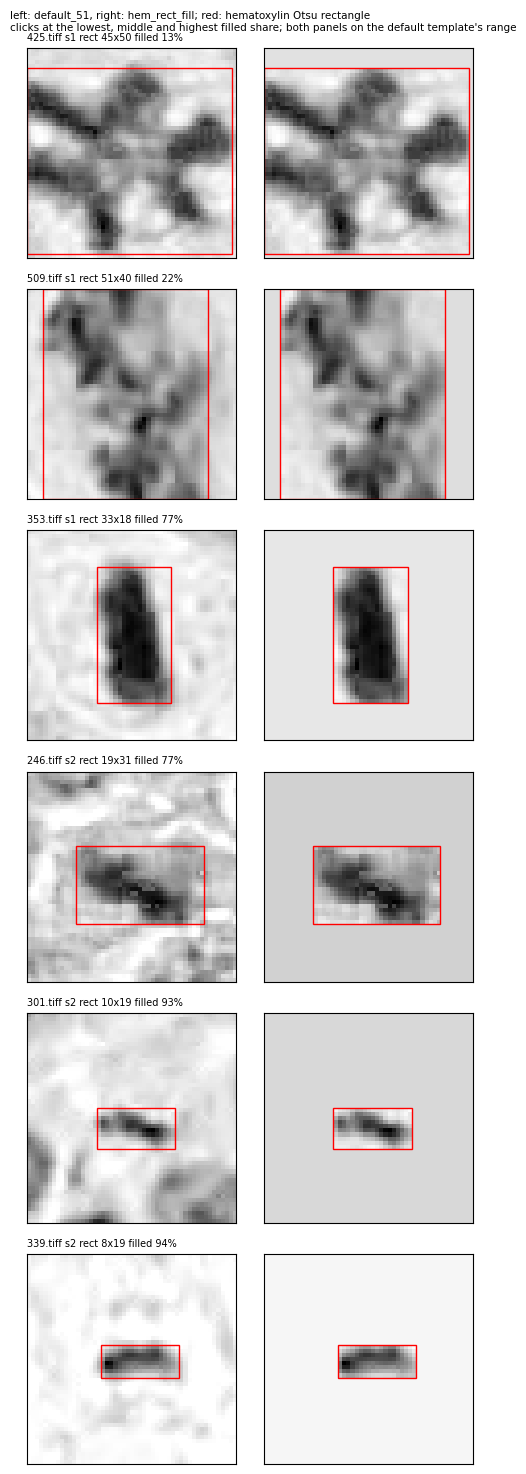

-> hemrectfill_49roi3seed_templates.png  (sorted positions [0, 1, 72, 73, 145, 146] of 147 clicks)
run loop 16.4 min; notebook 16.5 min


In [9]:
roi_pos = {fn: i for i, fn in enumerate(ROI_ORDER)}
fig_clicks = CLICK_TABLE.assign(_roi_o=CLICK_TABLE['file_name'].map(roi_pos)).sort_values(['filled_share', '_roi_o', 'seed_index'], kind='mergesort').reset_index(drop=True)
n = len(CLICKS)
positions = [0, 1, n // 2 - 1, n // 2, n - 2, n - 1]
fig, axes = plt.subplots(6, 2, figsize=(5, 15))
for row_axes, pos in zip(axes, positions):
    c = fig_clicks.iloc[pos]
    T, F, (y0, y1, x0, x1) = TEMPLATES[(c['file_name'], int(c['seed_index']))]
    for ax, img in zip(row_axes, (T, F)):
        ax.imshow(img, cmap='gray_r', vmin=T.min(), vmax=T.max())
        ax.add_patch(Rectangle((x0 - 0.5, y0 - 0.5), x1 - x0, y1 - y0, fill=False, edgecolor='red'))
        ax.set_xticks([])
        ax.set_yticks([])
    row_axes[0].set_title(f"{c['file_name']} s{int(c['seed_index'])} rect {int(c['rect_h'])}x{int(c['rect_w'])} filled {c['filled_share']:.0%}", fontsize=7, loc='left')
fig.suptitle('left: default_51, right: hem_rect_fill; red: hematoxylin Otsu rectangle\nclicks at the lowest, middle and highest filled share; both panels on the default template\'s range', fontsize=7.5, x=0.02, ha='left')
fig.tight_layout()
fig.savefig(FIG_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f"-> {FIG_PATH}  (sorted positions {positions} of {n} clicks)")
print(f"run loop {RUNTIME_LOOP_MIN:.1f} min; notebook {(time.time() - NB_T0) / 60:.1f} min")

## Results

Every number below is printed by a cell above. "Points" are percentage points of precision. Every delta is
`hem_rect_fill - default_51`.

**Parity gate (Cell 4).** All 147/147 `default_51` runs reproduce the recorded run, with no mismatches. That
covers `n_peaks`, `n_detections`, `n_self_hits`, TP@10/20/30, and the top-30 `rank`/`cx`/`cy`/`bucket`/`matched_ann_id`,
float32 `score` and `od`. `od` is bit-exact on 4410/4410 top-30 rows. The run loop took 16.4 min for 294 template
runs (median 2.52 s per `default_51` run, 2.47 s per `hem_rect_fill` run).

**Checks (Cell 5).**
- *Halt checks, all passed:*
  - every list delivered at least 30 candidates (294/294). `n_detections` is 81-100 for `default_51` and 84-100 for `hem_rect_fill`;
  - no NaN `od` and every list is `od`-descending (294/294 each);
  - one row per arm per click, with the same `seed_ann_id` and `n_gt_mitotic` (147/147);
  - the filled template keeps the default template's mean (147/147; max absolute gap 2.58e-09).
- *Report checks:*
  - `n_peaks == 100` on 147/147 runs in each arm;
  - no candidate within one match radius of the click, 147/147 in each arm;
  - `n_self_hits`: `default_51` {0: 2, 1: 145}, `hem_rect_fill` {0: 11, 1: 136};
  - `od` bit-exact against the recorded top-30: 4410/4410.
- *List lengths.* Per click, `n_detections` differs between the arms by -4 to +18. By count of clicks: {-4: 1, -3: 1, -2: 3,
  -1: 22, 0: 94, 1: 15, 2: 1, 3: 5, 4: 2, 5: 1, 10: 1, 18: 1}. Cell 0's caveat quoted "up to 3" from the dry run. Across
  all 147 clicks the difference is larger. Precision is still compared at fixed K, and every list delivers 30.

**Fill geometry (Cell 6), 147 clicks.**
- The hematoxylin rectangle is a median 25 x 26 px: height 8-51, width 12-51.
- Filled share is a median 0.7735 (0.1349-0.9416), so most clicks flatten about three quarters of the template.
- Fill value is a median 0.02818 (0.004407-0.1071).
- The rectangle touches the window edge on 9/147 clicks, and reaches 50 px or more on at least one side on 3/147.

**Pooled precision per arm (Cells 7-8).** Cluster-bootstrap 95% CI over ROIs. Each arm's CI is unpaired, so read
the difference from the paired table below.

| K | `default_51` | `hem_rect_fill` |
|---|---|---|
| 10 | 0.5694 [0.4932, 0.6435] (837/1470) | 0.5714 [0.4959, 0.6442] (840/1470) |
| 20 | 0.4969 [0.4238, 0.5690] (1461/2940) | 0.5017 [0.4299, 0.5718] (1475/2940) |
| 30 | 0.4331 [0.3635, 0.5032] (1910/4410) | 0.4424 [0.3730, 0.5120] (1951/4410) |

**Paired deltas (Cell 8).** 49 ROIs x 3 clicks. W/L/T is on the ROI's delta summed over its 3 clicks, and Holm
adjusts over the 3 K.

| K | pooled delta (pts) | bootstrap 95% CI (pts) | share of resamples at 0 or opposite | t 95% CI (pts) | ROI W/L/T | exact p | Holm p | min attainable p | D5 bar met | `d5_robustness` |
|---|---|---|---|---|---|---|---|---|---|---|
| 10 | +0.20 | [-1.09, +1.56] | 0.4054 | [-1.14, +1.55] | 10/9/30 | 0.846 | 1 | 3.81e-06 | no (10/49 same direction) | not met |
| 20 | +0.48 | [-0.51, +1.70] | 0.2133 | [-0.66, +1.61] | 19/16/14 | 0.505 | 1 | 5.82e-11 | no (19/49) | not met |
| 30 | +0.93 | [+0.05, +2.04] | 0.019 | [-0.09, +1.95] | 20/14/15 | 0.0619 | 0.186 | 1.16e-10 | no (20/49) | not met |

Descriptive only: click-level W/L/T is 18/15/114 at K=10, 30/29/88 at K=20 and 39/32/76 at K=30.
- Per domain, `human neuroendocrine tumor` is the only domain below 0 at every K (-1.43, -1.67, -1.27 points).
- `canine lymphosarcoma` has the largest K=30 delta (+3.49 points, ROI W/L/T 5/2/0).

**Reading, by Cell 0's rules.**
- **K = 10:** the bootstrap CI includes 0, so no difference is detected. The bound is [-1.09, +1.56] points.
- **K = 20:** the bootstrap CI includes 0, so no difference is detected. The bound is [-0.51, +1.70] points.
- **K = 30:** the bootstrap CI excludes 0 and the delta is > 0. By the fixed rule, this reads as flattening the
  surround outside the hematoxylin rectangle raising precision@30, by +0.93 points [+0.05, +2.04]. The reading
  rests on a lower bound of +0.05 points, and 0.019 of resamples land at 0 or below. The rest of the same row
  doesn't back it up:
  - the t interval over the same ROI deltas includes 0 ([-0.09, +1.95]);
  - the exact sign-flip p is 0.0619 (Holm 0.186);
  - only 20 of 49 ROIs go up (14 down, 15 tied), so the D5 bar is not met, and `d5_robustness` labels the row "not met".

Descriptive, for K = 30: the pooled gain is +41 TP (1951 - 1910). One click, `291.tiff` s0, goes from 5 to 16 TP@30
(Cell 4), which is +11 of that total.

This run does not measure why any of these changes happen.